# KeyMonkey — Grand Model Comparison

Loads all trained checkpoints and produces a unified evaluation across every model.

**Models compared**
| Model | Type | Notebook |
|---|---|---|
| Vanilla RNN | Recurrent neural net | `KeyMonkey_model_final` |
| GRU | Recurrent neural net | `KeyMonkey_model_final` |
| LSTM | Recurrent neural net | `KeyMonkey_model_final` |
| LightGBM | Gradient-boosted trees | `KeyMonkey_rf_svm_final` |
| SGD-SVM | Linear SVM (hinge loss) | `KeyMonkey_rf_svm_final` |

**Prerequisites**
- Preprocessing notebook run to completion (`maestro_cache/` exists)
- All model notebooks run to completion (checkpoints saved to `maestro_checkpoints/`)

**Required checkpoint files**
```
maestro_checkpoints/
  best_RNN.pt
  best_GRU.pt
  best_LSTM.pt
  lgbm_estimators.pkl
  svm_model.pkl
```

## Step 1 — Setup

In [ ]:
!pip install lightgbm scikit-learn -q

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import joblib
import random
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
from sklearn.metrics import f1_score, accuracy_score, hamming_loss
from collections import defaultdict
from tqdm.notebook import tqdm

DRIVE_ROOT = Path('/content/drive/My Drive/Key Monkey')
CACHE_DIR  = DRIVE_ROOT / 'maestro_cache'
CKPT_DIR   = DRIVE_ROOT / 'maestro_checkpoints'

N_PITCHES  = 88
MAX_FRAMES = 512
BATCH_SIZE = 32
WINDOW_SIZE      = 16
STRIDE           = 4
BINARIZE_THRESH  = 0.3
MAX_TEST_SAMPLES = 20_000

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'Cache  : {CACHE_DIR}')
print(f'Checkpoints: {CKPT_DIR}')
assert CACHE_DIR.exists(), 'Cache not found — run preprocessing notebook first.'

# Verify all checkpoints exist
required = ['best_RNN.pt', 'best_GRU.pt', 'best_LSTM.pt',
            'lgbm_estimators.pkl', 'svm_model.pkl']
missing = [f for f in required if not (CKPT_DIR / f).exists()]
if missing:
    print(f'\n Missing checkpoints: {missing}')
    print('Run the relevant model notebooks first.')
else:
    print('\n✓ All checkpoints found.')

Mounted at /content/drive
Device : cpu
Cache  : /content/drive/My Drive/Key Monkey/maestro_cache
Checkpoints: /content/drive/My Drive/Key Monkey/maestro_checkpoints

✓ All checkpoints found.


## Step 2 — Model Definitions

Identical architectures to `KeyMonkey_model_final` — needed to load the `.pt` checkpoints.

In [ ]:
class VanillaRNN(nn.Module):
    def __init__(self, n=N_PITCHES, hidden=256, layers=2, drop=0.3):
        super().__init__()
        self.rnn = nn.RNN(n, hidden, layers, batch_first=True, dropout=drop, nonlinearity='tanh')
        self.fc  = nn.Linear(hidden, n)

    def forward(self, x, h=None):
        out, h = self.rnn(x, h)
        return self.fc(out), h


class GRUModel(nn.Module):
    def __init__(self, n=N_PITCHES, hidden=256, layers=2, drop=0.3):
        super().__init__()
        self.gru = nn.GRU(n, hidden, layers, batch_first=True, dropout=drop)
        self.fc  = nn.Linear(hidden, n)

    def forward(self, x, h=None):
        out, h = self.gru(x, h)
        return self.fc(out), h


class LSTMModel(nn.Module):
    def __init__(self, n=N_PITCHES, hidden=256, layers=2, drop=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n, hidden, layers, batch_first=True, dropout=drop)
        self.fc   = nn.Linear(hidden, n)

    def forward(self, x, h=None):
        out, h = self.lstm(x, h)
        return self.fc(out), h


for name, cls in [('VanillaRNN', VanillaRNN), ('GRU', GRUModel), ('LSTM', LSTMModel)]:
    p = sum(x.numel() for x in cls().parameters())
    print(f'{name:12s}: {p:>8,} parameters')

VanillaRNN  :  242,776 parameters
GRU         :  683,096 parameters
LSTM        :  903,256 parameters


## Step 3 — Datasets and DataLoaders

In [ ]:
# ── Neural net dataset (sequential frames) ────────────────────────────────────
class MaestroDataset(Dataset):
    def __init__(self, split, max_frames=MAX_FRAMES):
        index_path = CACHE_DIR / f'{split}_index.txt'
        with open(index_path) as f:
            self.files = [CACHE_DIR / l.strip() for l in f if l.strip()]
        self.max_frames = max_frames

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        roll = np.load(str(self.files[idx]))['roll'].astype(np.float32)
        T    = roll.shape[0]
        if T >= self.max_frames:
            s    = random.randint(0, T - self.max_frames)
            clip = roll[s : s + self.max_frames]
        else:
            clip = np.vstack([roll, np.zeros((self.max_frames - T, N_PITCHES), np.float32)])
        return torch.from_numpy(clip[:-1]), torch.from_numpy(clip[1:])


# ── Classical ML dataset (sliding windows) ────────────────────────────────────
def load_windows(split_name, max_samples, window_size=WINDOW_SIZE, stride=STRIDE):
    index_path = CACHE_DIR / f'{split_name}_index.txt'
    with open(index_path) as f:
        files = [CACHE_DIR / l.strip() for l in f if l.strip()]
    rng = np.random.default_rng(42)
    files = list(files)
    rng.shuffle(files)
    all_X, all_y = [], []
    for fpath in files:
        if len(all_X) >= max_samples:
            break
        try:
            roll = np.load(str(fpath))['roll']
        except Exception:
            continue
        T = roll.shape[0]
        if T <= window_size:
            continue
        for i in range(0, T - window_size, stride):
            all_X.append(roll[i : i + window_size].flatten().astype(np.float32))
            all_y.append((roll[i + window_size] > BINARIZE_THRESH).astype(np.uint8))
            if len(all_X) >= max_samples:
                break
    return np.array(all_X, dtype=np.float32), np.array(all_y, dtype=np.uint8)


print('Building neural net test loader...')
test_loader = DataLoader(
    MaestroDataset('test'), BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print('Building classical ML test windows...')
X_test_ml, y_test_ml = load_windows('test', MAX_TEST_SAMPLES)
print(f'ML test set: {X_test_ml.shape[0]:,} windows | {X_test_ml.shape[1]} features')
print(f'Neural test : {len(test_loader.dataset)} files')

Building neural net test loader...
Building classical ML test windows...
ML test set: 20,000 windows | 1408 features
Neural test : 177 files


## Step 4 — Load All Checkpoints

In [ ]:
import numpy as np
from sklearn.linear_model import SGDClassifier

class SafeSGD:
    def __init__(self, alpha=0.0001, max_iter=100, tol=0.001):
        self.alpha    = alpha
        self.max_iter = max_iter
        self.tol      = tol
        self._clf     = SGDClassifier(class_weight='balanced', max_iter=max_iter,
                                      n_jobs=1, random_state=42)
        self._const   = None

    def fit(self, X, y):
        unique = np.unique(y)
        if len(unique) == 1:
            self._const = unique[0]
            self._clf   = None
        else:
            self._clf.fit(X, y)
        return self

    def predict(self, X):
        if self._const is not None:
            return np.full(X.shape[0], self._const, dtype=self.classes_[0].dtype)
        return self._clf.predict(X)

    def __getattr__(self, name):
        if name in ('_clf', '_const'):
            raise AttributeError(name)
        return getattr(self._clf, name)

# Reload with the correct class now in scope
svm_bundle = joblib.load(str(CKPT_DIR / 'svm_model.pkl'))
svm_model  = svm_bundle['model']
svm_scaler = svm_bundle['scaler']
print('  Loaded.')

  Loaded.


In [ ]:
# ── Neural nets ───────────────────────────────────────────────────────────────
def load_rnn_checkpoint(model_class, name):
    ckpt  = torch.load(str(CKPT_DIR / f'best_{name}.pt'), map_location=device, weights_only=False)
    model = model_class().to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    threshold = ckpt.get('threshold', 0.3)
    val_loss  = ckpt.get('val_loss', float('nan'))
    params    = sum(p.numel() for p in model.parameters())
    print(f'  {name:6s} | params: {params:,} | val_loss: {val_loss:.4f} | threshold: {threshold:.2f}')
    return model, threshold

print('Loading neural net checkpoints...')
rnn_model,  rnn_thresh  = load_rnn_checkpoint(VanillaRNN, 'RNN')
gru_model,  gru_thresh  = load_rnn_checkpoint(GRUModel,   'GRU')
lstm_model, lstm_thresh = load_rnn_checkpoint(LSTMModel,  'LSTM')


# ── LightGBM ──────────────────────────────────────────────────────────────────
print('\nLoading LightGBM estimators...')
lgb_estimators = joblib.load(str(CKPT_DIR / 'lgbm_estimators.pkl'))
n_lgb = sum(1 for e in lgb_estimators if not isinstance(e, int))
print(f'  {n_lgb}/88 pitch classifiers loaded ({88 - n_lgb} constant-class pitches)')


# ── SGD-SVM ───────────────────────────────────────────────────────────────────
print('\nLoading SGD-SVM...')
svm_bundle = joblib.load(str(CKPT_DIR / 'svm_model.pkl'))
svm_model  = svm_bundle['model']
svm_scaler = svm_bundle['scaler']
print('  Loaded.')

print('\n✓ All models ready.')

Loading neural net checkpoints...
  RNN    | params: 242,776 | val_loss: 0.1660 | threshold: 0.65
  GRU    | params: 683,096 | val_loss: 0.1542 | threshold: 0.65
  LSTM   | params: 903,256 | val_loss: 0.1576 | threshold: 0.65

Loading LightGBM estimators...
  85/88 pitch classifiers loaded (3 constant-class pitches)

Loading SGD-SVM...
  Loaded.

✓ All models ready.


## Step 5 — Evaluation Helpers

In [ ]:
def compute_metrics(y_true, y_pred, name):
    """Compute the full metric suite for one model."""
    exact    = accuracy_score(y_true, y_pred)
    hamm     = 1 - hamming_loss(y_true, y_pred)
    f1_mac   = f1_score(y_true, y_pred, average='macro',   zero_division=0)
    f1_mic   = f1_score(y_true, y_pred, average='micro',   zero_division=0)
    f1_samp  = f1_score(y_true, y_pred, average='samples', zero_division=0)
    per_pitch= f1_score(y_true, y_pred, average=None,      zero_division=0)

    # Silence rate for skill score
    silence_rate = 1 - y_true.mean()
    skill = hamm - silence_rate        # accuracy gain over always-predict-silence baseline

    print(f'  {name}')
    print(f'  Exact Match : {exact:.4f}')
    print(f'  Hamming Acc : {hamm:.4f}  (silence baseline: {silence_rate:.4f}, skill: {skill:+.4f})')
    print(f'  F1 Macro    : {f1_mac:.4f}')
    print(f'  F1 Micro    : {f1_mic:.4f}')
    print(f'  F1 Sample   : {f1_samp:.4f}')
    print()

    return {
        'name': name,
        'exact_match':  exact,
        'hamming_acc':  hamm,
        'f1_macro':     f1_mac,
        'f1_micro':     f1_mic,
        'f1_sample':    f1_samp,
        'skill':        skill,
        'per_pitch_f1': per_pitch,
    }


def eval_rnn(model, loader, threshold, name):
    """Run inference on the sequential test loader for RNN/GRU/LSTM."""
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f'Eval {name}', leave=False):
            x, y = x.to(device), y.to(device)
            with autocast('cuda'):
                logits, _ = model(x)
            all_preds.append(  (torch.sigmoid(logits) > threshold).cpu().numpy())
            all_targets.append((y > 0.5).cpu().numpy())
    P = np.vstack(all_preds).reshape(-1, N_PITCHES).astype(np.uint8)
    T = np.vstack(all_targets).reshape(-1, N_PITCHES).astype(np.uint8)
    return compute_metrics(T, P, name)


def lgb_predict_proba(estimators, X):
    """(N, 88) probability array; constant-class pitches get 0.0 or 1.0."""
    cols = []
    for est in estimators:
        if isinstance(est, int):
            cols.append(np.full(len(X), float(est)))
        else:
            cols.append(est.predict_proba(X)[:, 1])
    return np.column_stack(cols)


# ── Threshold search helper (used for LightGBM on test) ───────────────────────
def best_threshold_from_val(estimators, X_val, y_val, n_steps=17):
    val_probs = lgb_predict_proba(estimators, X_val)
    best_t, best_f1 = 0.3, 0.0
    for t in np.linspace(0.1, 0.9, n_steps):
        preds = (val_probs > t).astype(np.uint8)
        f1 = f1_score(y_val, preds, average='micro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f'  LightGBM threshold: {best_t:.2f} (val micro-F1: {best_f1:.4f})')
    return best_t


print('Helpers ready.')

Helpers ready.


## Step 6 — Run All Evaluations

Neural nets run on the sequential test loader (full files, frame-by-frame).  
LightGBM and SVM run on the sliding-window test set (same data, different representation).

In [ ]:
# LightGBM needs a val set to fix its threshold first
print('Loading validation windows for LightGBM threshold...')
X_val_ml, y_val_ml = load_windows('validation', 20_000)
lgb_best_thresh = best_threshold_from_val(lgb_estimators, X_val_ml, y_val_ml)

Loading validation windows for LightGBM threshold...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  LightGBM threshold: 0.80 (val micro-F1: 0.8665)


In [ ]:
est = next(e for e in svm_model.estimators_ if e is not None)
print("Type:", type(est))
print("\nAttributes:")
for k, v in vars(est).items():
    print(f"  {k}: {type(v).__name__} = {repr(v) if not hasattr(v, 'shape') else v.shape}")

Type: <class '__main__.SafeSGD'>

Attributes:
  alpha: float = 0.0001
  max_iter: int = 100
  tol: float = 0.001
  _clf: SGDClassifier = SGDClassifier(class_weight='balanced', max_iter=100, n_jobs=1, random_state=42)
  _const: NoneType = None
  classes_: ndarray = (2,)


In [ ]:
print('=' * 60)
print('  EVALUATING ALL MODELS ON TEST SET')
print('=' * 60)
results = {}

# ── RNN ───────────────────────────────────────────────────────────────────────
results['RNN'] = eval_rnn(rnn_model, test_loader, rnn_thresh, 'RNN')

# ── GRU ───────────────────────────────────────────────────────────────────────
results['GRU'] = eval_rnn(gru_model, test_loader, gru_thresh, 'GRU')

# ── LSTM ──────────────────────────────────────────────────────────────────────
results['LSTM'] = eval_rnn(lstm_model, test_loader, lstm_thresh, 'LSTM')

# ── LightGBM ──────────────────────────────────────────────────────────────────
print('Evaluating LightGBM...')
lgb_probs       = lgb_predict_proba(lgb_estimators, X_test_ml)
lgb_preds       = (lgb_probs > lgb_best_thresh).astype(np.uint8)
results['LightGBM'] = compute_metrics(y_test_ml, lgb_preds, 'LightGBM')

from sklearn.dummy import DummyClassifier
import numpy as np

# Patch None estimators (constant-class pitches — always predict 0)
for i, est in enumerate(svm_model.estimators_):
    if est is None:
        dummy = DummyClassifier(strategy='constant', constant=0)
        # Fit on a minimal dummy dataset so it's callable
        dummy.fit([[0]] * 2, [0, 0])
        svm_model.estimators_[i] = dummy

# Now predict normally
X_test_sc  = svm_scaler.transform(X_test_ml)
svm_preds  = svm_model.predict(X_test_sc).astype(np.uint8)
results['SGD-SVM'] = compute_metrics(y_test_ml, svm_preds, 'SGD-SVM')

print('=' * 60)
print('  DONE')
print('=' * 60)

  EVALUATING ALL MODELS ON TEST SET


Eval RNN:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_2794/645529402.py:41: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast('cuda'):


  RNN
  Exact Match : 0.6628
  Hamming Acc : 0.9924  (silence baseline: 0.9477, skill: +0.0447)
  F1 Macro    : 0.8320
  F1 Micro    : 0.9288
  F1 Sample   : 0.8091



Eval GRU:   0%|          | 0/6 [00:00<?, ?it/s]

...

Eval LSTM:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_2794/645529402.py:41: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast('cuda'):


  LSTM
  Exact Match : 0.6698
  Hamming Acc : 0.9927  (silence baseline: 0.9498, skill: +0.0429)
  F1 Macro    : 0.8129
  F1 Micro    : 0.9285
  F1 Sample   : 0.8005

Evaluating LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  LightGBM
  Exact Match : 0.0582
  Hamming Acc : 0.9830  (silence baseline: 0.9536, skill: +0.0294)
  F1 Macro    : 0.8079
  F1 Micro    : 0.8359
  F1 Sample   : 0.6867

  SGD-SVM
  Exact Match : 0.4011
  Hamming Acc : 0.9836  (silence baseline: 0.9536, skill: +0.0300)
  F1 Macro    : 0.7125
  F1 Micro    : 0.8308
  F1 Sample   : 0.7051

  DONE


## Step 7 — Summary Table

In [ ]:
models      = list(results.keys())
metric_keys = ['exact_match', 'hamming_acc', 'f1_macro', 'f1_micro', 'f1_sample', 'skill']
metric_lbls = ['Exact Match', 'Hamming Acc', 'F1 Macro ★', 'F1 Micro', 'F1 Sample', 'Skill Score']

col_w   = 12
name_w  = 10
header  = f"{'Model':<{name_w}}" + ''.join(f"{m:>{col_w}}" for m in metric_lbls)
divider = '-' * len(header)

print(divider)
print(header)
print(divider)

# Find best value per metric for highlighting
best = {k: max(results[m][k] for m in models) for k in metric_keys}

for name in models:
    row = f"{name:<{name_w}}"
    for k in metric_keys:
        v   = results[name][k]
        tag = '✓' if abs(v - best[k]) < 1e-6 else ' '
        row += f"{v:>{col_w - 1}.4f}{tag}"
    print(row)

print(divider)
print('  ★ Headline metric. Skill Score = Hamming Acc − silence baseline.')
print('  ✓ = best in column.')

----------------------------------------------------------------------------------
Model      Exact Match Hamming Acc  F1 Macro ★    F1 Micro   F1 Sample Skill Score
----------------------------------------------------------------------------------
RNN            0.6628      0.9924      0.8320      0.9288      0.8091      0.0447 
GRU            0.6759✓     0.9930✓     0.8334✓     0.9333✓     0.8166✓     0.0448✓
LSTM           0.6698      0.9927      0.8129      0.9285      0.8005      0.0429 
LightGBM       0.0582      0.9830      0.8079      0.8359      0.6867      0.0294 
SGD-SVM        0.4011      0.9836      0.7125      0.8308      0.7051      0.0300 
----------------------------------------------------------------------------------
  ★ Headline metric. Skill Score = Hamming Acc − silence baseline.
  ✓ = best in column.


## Step 8 — Grand Comparison Chart

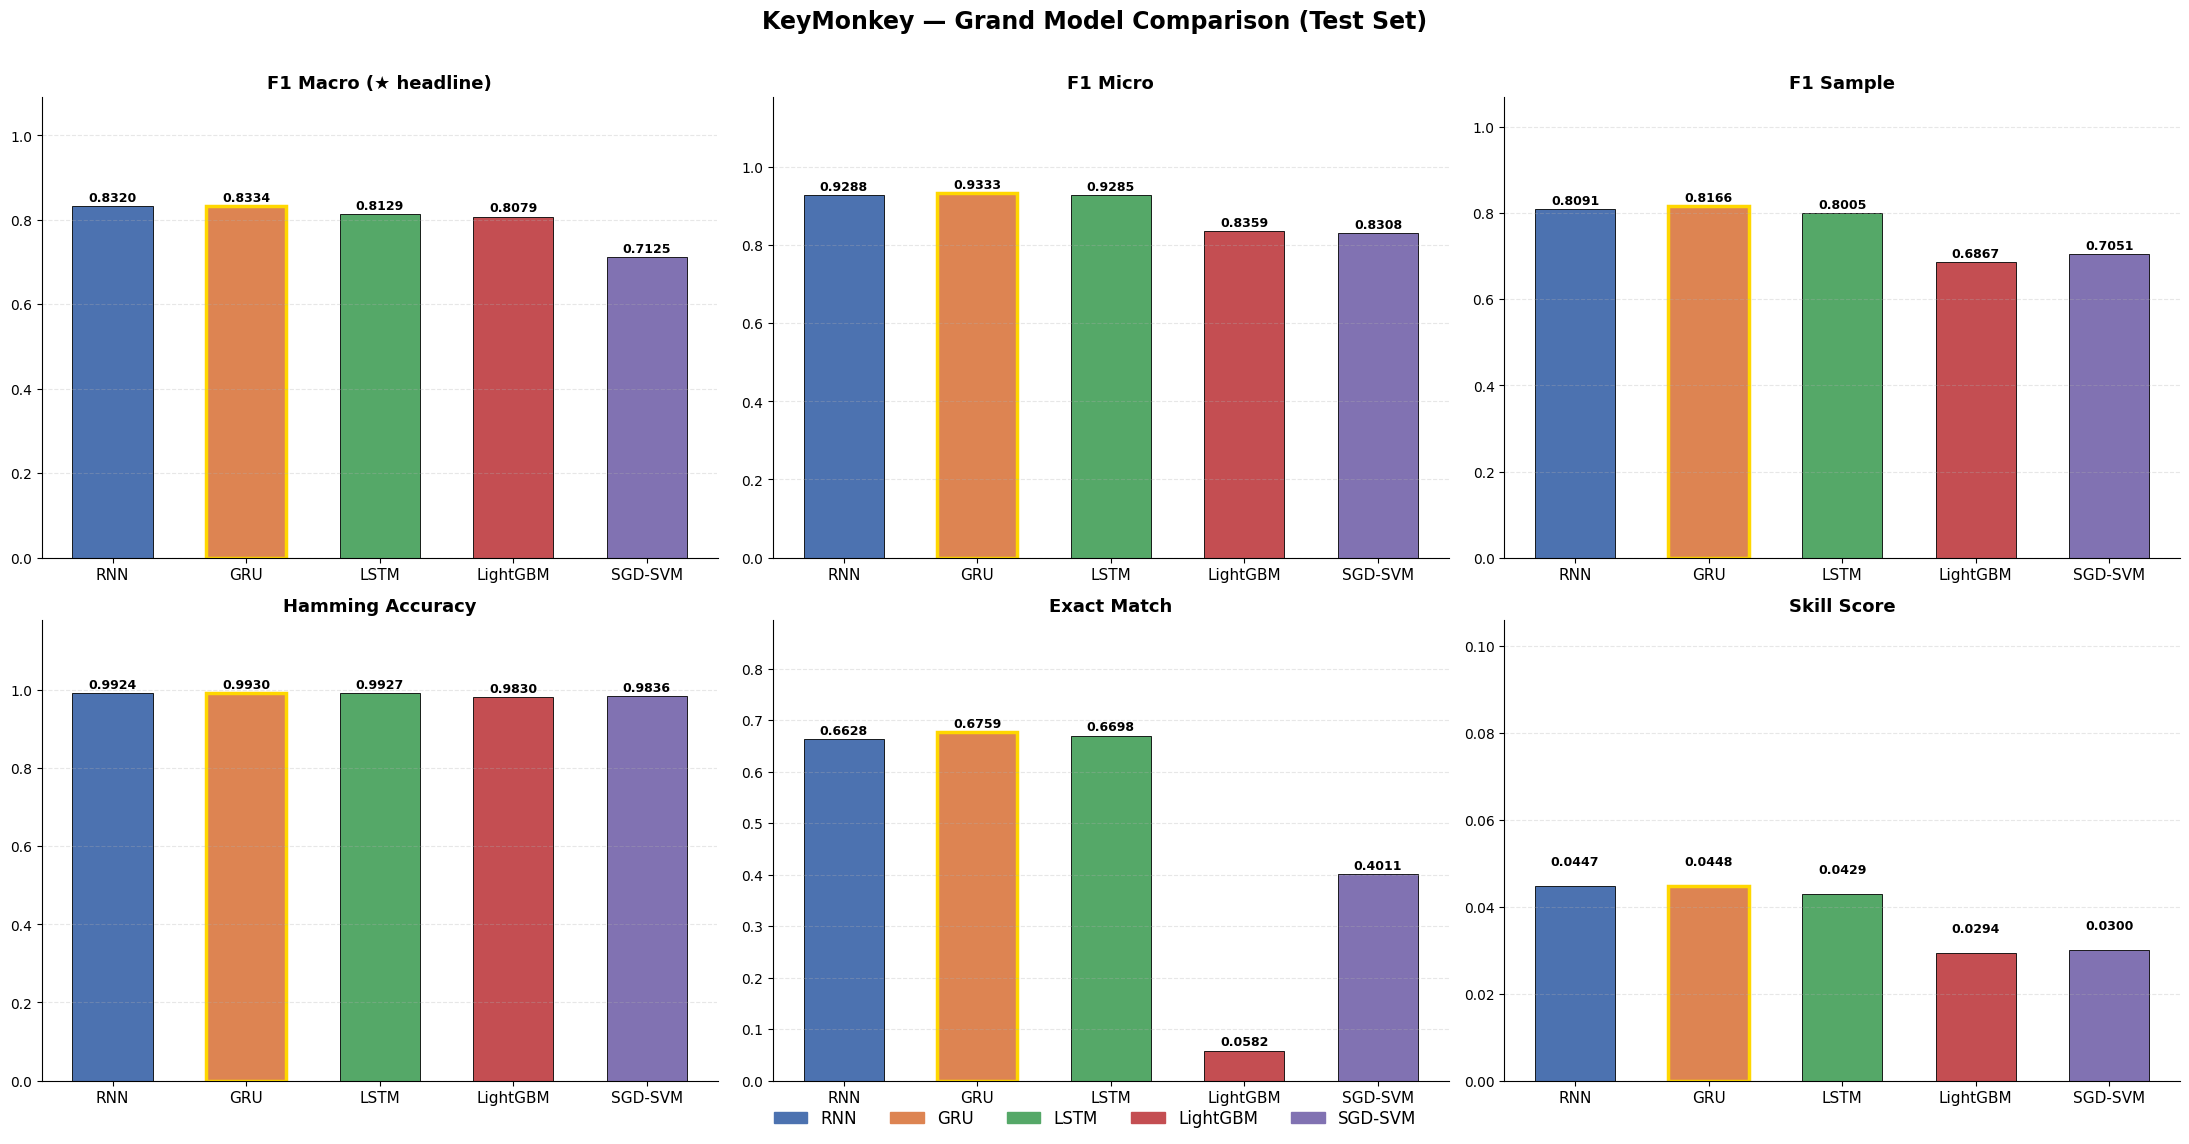

Saved to /content/drive/My Drive/Key Monkey/maestro_checkpoints/grand_comparison.png


In [ ]:
COLORS = {
    'RNN':      '#4C72B0',
    'GRU':      '#DD8452',
    'LSTM':     '#55A868',
    'LightGBM': '#C44E52',
    'SGD-SVM':  '#8172B2',
}

plot_metrics = [
    ('f1_macro',    'F1 Macro (★ headline)'),
    ('f1_micro',    'F1 Micro'),
    ('f1_sample',   'F1 Sample'),
    ('hamming_acc', 'Hamming Accuracy'),
    ('exact_match', 'Exact Match'),
    ('skill',       'Skill Score'),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 11))
axes      = axes.flatten()

x     = np.arange(len(models))
bar_c = [COLORS[m] for m in models]

for ax, (key, label) in zip(axes, plot_metrics):
    vals  = [results[m][key] for m in models]
    bars  = ax.bar(x, vals, color=bar_c, edgecolor='black', linewidth=0.6, width=0.6)
    best_v = max(vals)

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.004,
            f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold',
        )
        if abs(v - best_v) < 1e-6:
            bar.set_edgecolor('#FFD700')
            bar.set_linewidth(2.5)

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylim(0, min(1.18, max(vals) * 1.25 + 0.05))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

legend_patches = [Patch(color=COLORS[m], label=m) for m in models]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=5,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    'KeyMonkey — Grand Model Comparison (Test Set)',
    fontsize=17, fontweight='bold', y=1.01,
)
plt.tight_layout()
out_path = str(CKPT_DIR / 'grand_comparison.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')

## Step 9 — Per-Pitch F1 Heatmap

Shows which piano keys each model handles well and where each struggles.
Low F1 at the extreme registers (A0, B7, C8) is expected — those notes are rare in MAESTRO.

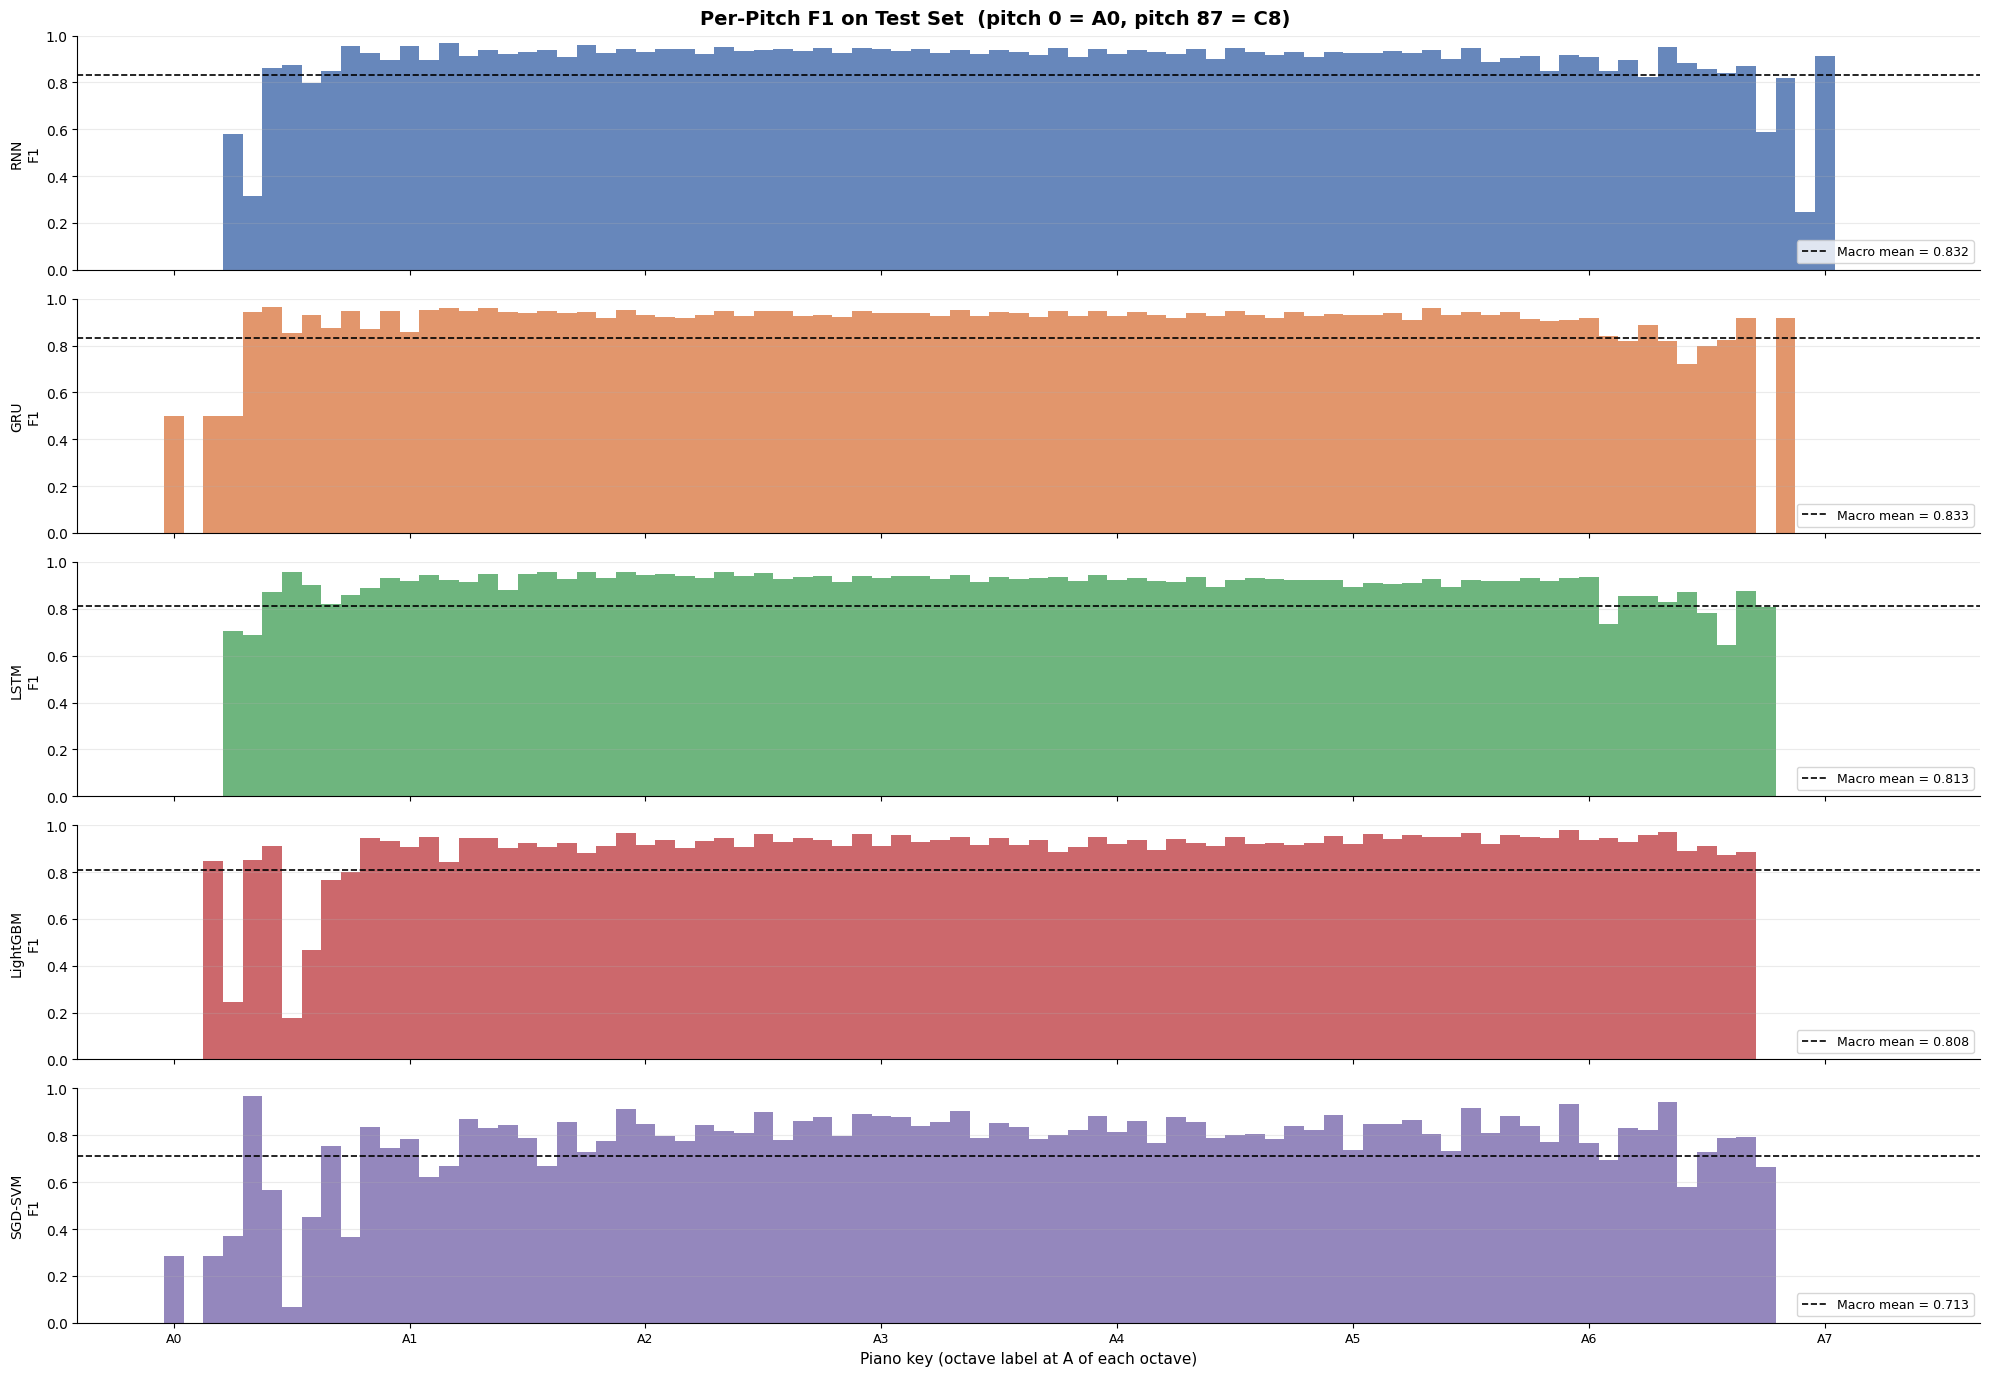

Saved to /content/drive/My Drive/Key Monkey/maestro_checkpoints/per_pitch_f1_all_models.png


In [ ]:
fig, axes = plt.subplots(len(models), 1, figsize=(20, 2.8 * len(models)), sharex=True)
fig.suptitle(
    'Per-Pitch F1 on Test Set  (pitch 0 = A0, pitch 87 = C8)',
    fontsize=14, fontweight='bold',
)

octave_ticks  = np.arange(0, N_PITCHES, 12)
octave_labels = [f'A{o}' for o in range(8)]

for ax, name in zip(axes, models):
    pp = results[name]['per_pitch_f1']
    ax.bar(np.arange(N_PITCHES), pp, color=COLORS[name], alpha=0.85, width=1.0)
    ax.axhline(results[name]['f1_macro'], color='black', linestyle='--',
               linewidth=1.2, label=f'Macro mean = {results[name]["f1_macro"]:.3f}')
    ax.set_ylim(0, 1)
    ax.set_ylabel(f'{name}\nF1', fontsize=10)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='y', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xticks(octave_ticks)
axes[-1].set_xticklabels(octave_labels, fontsize=9)
axes[-1].set_xlabel('Piano key (octave label at A of each octave)', fontsize=11)

plt.tight_layout()
out_path = str(CKPT_DIR / 'per_pitch_f1_all_models.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')

## Step 10 — Radar Chart (Shape of Performance)

Shows the overall performance profile of each model across all metrics at a glance.

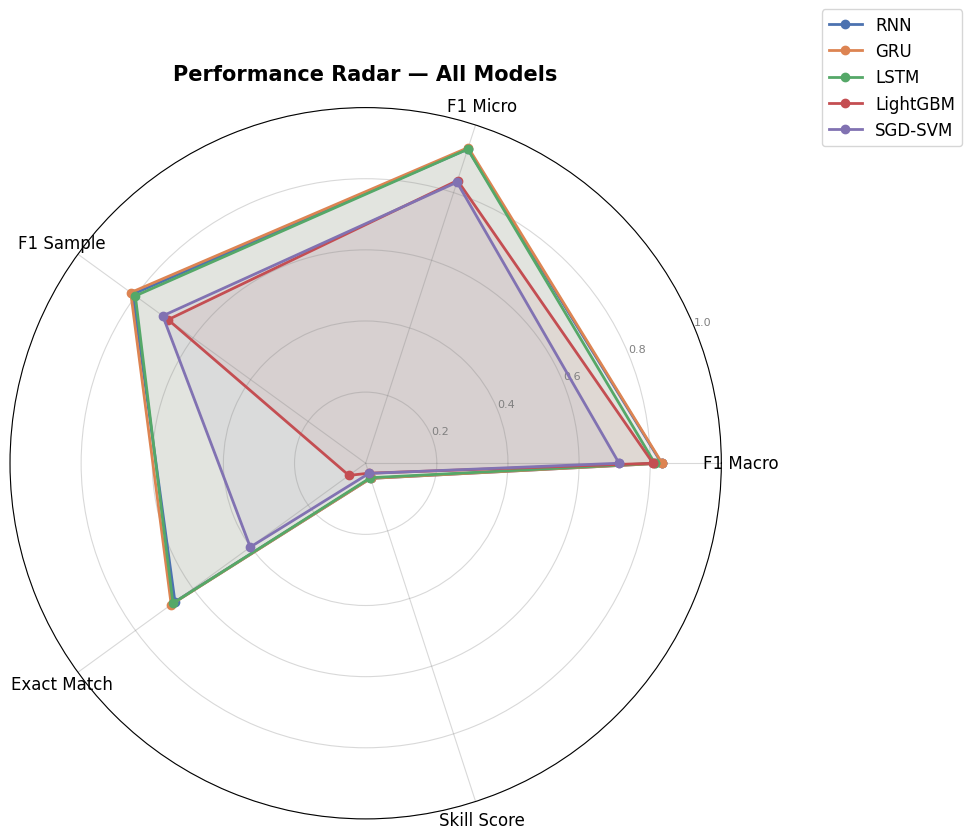

Saved to /content/drive/My Drive/Key Monkey/maestro_checkpoints/radar_chart.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

radar_keys = ['f1_macro', 'f1_micro', 'f1_sample', 'exact_match', 'skill']
radar_lbls = ['F1 Macro', 'F1 Micro', 'F1 Sample', 'Exact Match', 'Skill Score']
N_axes     = len(radar_keys)

angles = np.linspace(0, 2 * np.pi, N_axes, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for name in models:
    vals = [results[name][k] for k in radar_keys]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=COLORS[name], label=name)
    ax.fill(angles, vals, alpha=0.08, color=COLORS[name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_lbls, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8, color='grey')
ax.grid(color='grey', alpha=0.3)
ax.set_title('Performance Radar — All Models', fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=12)

plt.tight_layout()
out_path = str(CKPT_DIR / 'radar_chart.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')

## Step 11 — Final Verdict

In [ ]:
ranked = sorted(models, key=lambda m: results[m]['f1_macro'], reverse=True)

print('=' * 60)
print('  FINAL RANKING BY F1 MACRO (headline metric)')
print('=' * 60)
medals = ['🥇', '🥈', '🥉', '  4.', '  5.']
for i, name in enumerate(ranked):
    r = results[name]
    print(f"{medals[i]}  {name:<10}  F1 Macro: {r['f1_macro']:.4f}  "
          f"F1 Micro: {r['f1_micro']:.4f}  Skill: {r['skill']:+.4f}")
print('=' * 60)

winner = ranked[0]
runner = ranked[1]
margin = results[winner]['f1_macro'] - results[runner]['f1_macro']
print(f"\nWinner: {winner}  (leads {runner} by {margin:.4f} F1 Macro)")

# Model family comparison
nn_best  = max(['RNN','GRU','LSTM'],     key=lambda m: results[m]['f1_macro'])
ml_best  = max(['LightGBM','SGD-SVM'],   key=lambda m: results[m]['f1_macro'])
nn_score = results[nn_best]['f1_macro']
ml_score = results[ml_best]['f1_macro']
print(f"\nBest neural net  : {nn_best:<10} F1 Macro = {nn_score:.4f}")
print(f"Best classical ML: {ml_best:<10} F1 Macro = {ml_score:.4f}")
if nn_score > ml_score:
    print(f"→ Neural nets win by {nn_score - ml_score:.4f} — sequence modelling pays off.")
else:
    print(f"→ Classical ML wins by {ml_score - nn_score:.4f} — surprising given the fixed window context.")

  FINAL RANKING BY F1 MACRO (headline metric)
🥇  GRU         F1 Macro: 0.8334  F1 Micro: 0.9333  Skill: +0.0448
🥈  RNN         F1 Macro: 0.8320  F1 Micro: 0.9288  Skill: +0.0447
🥉  LSTM        F1 Macro: 0.8129  F1 Micro: 0.9285  Skill: +0.0429
  4.  LightGBM    F1 Macro: 0.8079  F1 Micro: 0.8359  Skill: +0.0294
  5.  SGD-SVM     F1 Macro: 0.7125  F1 Micro: 0.8308  Skill: +0.0300

Winner: GRU  (leads RNN by 0.0015 F1 Macro)

Best neural net  : GRU        F1 Macro = 0.8334
Best classical ML: LightGBM   F1 Macro = 0.8079
→ Neural nets win by 0.0255 — sequence modelling pays off.
